In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Telco_Customer_Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum().sum()


np.int64(0)

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df["customerID"].duplicated().sum()

np.int64(0)

In [10]:
def conv(value):
    if value == 1:
        return 'Yes'
    else:
        return 'No'

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

# Converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

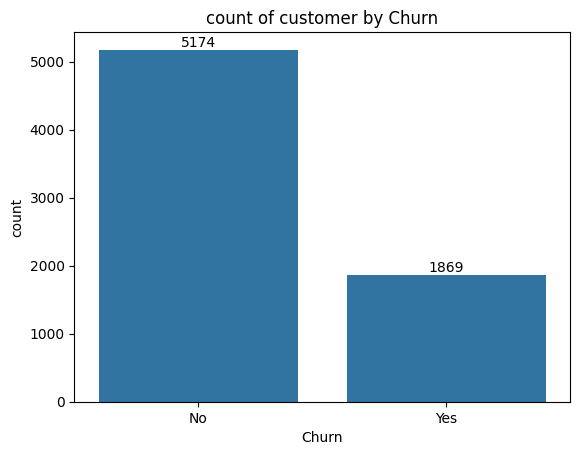

In [11]:
ax = sns.countplot(x = 'Churn',data = df)

ax.bar_label(ax.containers[0])
plt.title("count of customer by Churn")
plt.show()

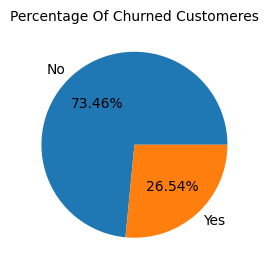

In [12]:
plt.figure(figsize = (3,4))
gb = df.groupby('Churn').agg({'Churn':"count"})
gb
plt.pie(gb['Churn'],labels = gb.index,autopct = "%1.2f%%")
plt.title("Percentage Of Churned Customeres",fontsize = 10)
plt.show()


# from the given pie chart we can conclued tha 26.54% of our customers have churned out .
## not lets explore the reason behind it

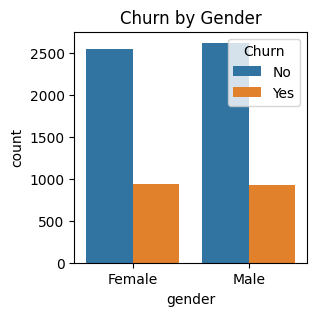

In [13]:
plt.figure (figsize= (3,3))
sns .countplot(x= "gender",data = df,hue = "Churn")
plt.title("Churn by Gender")
plt.show()

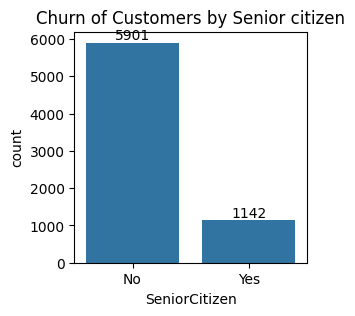

In [14]:
plt.figure (figsize= (3,3))
ax=sns.countplot(x= "SeniorCitizen",data = df)
ax.bar_label(ax.containers[0])
plt.title("Churn of Customers by Senior citizen")
plt.show()

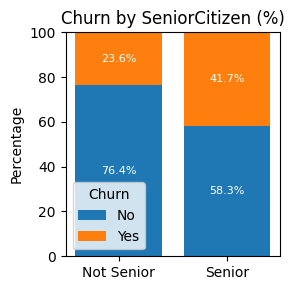

In [15]:
counts = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Step 2: Convert to percentage (row-wise normalization)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Step 3: Plot stacked bar chart
fig, ax = plt.subplots(figsize=(3, 3))

bottom = [0] * len(percentages)
x_labels = ['Not Senior', 'Senior']

# Plot each 'Churn' category as a stacked bar segment
for churn_status in counts.columns:
    values = percentages[churn_status]
    bars = ax.bar(x_labels, values, bottom=bottom, label=churn_status)

    # Add percentage labels
    for i, (bar, pct) in enumerate(zip(bars, values)):
        if pct > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[i] + pct / 2,
                    f'{pct:.1f}%',
                    ha='center', va='center', color='white', fontsize=8)
    bottom = [i + j for i, j in zip(bottom, values)]

# Final formatting
ax.set_title("Churn by SeniorCitizen (%)")
ax.set_ylabel("Percentage")
ax.set_ylim(0, 100)
ax.legend(title="Churn")
plt.tight_layout()
plt.show()

# comparative a greated percentage of people in senior citizen category have churned

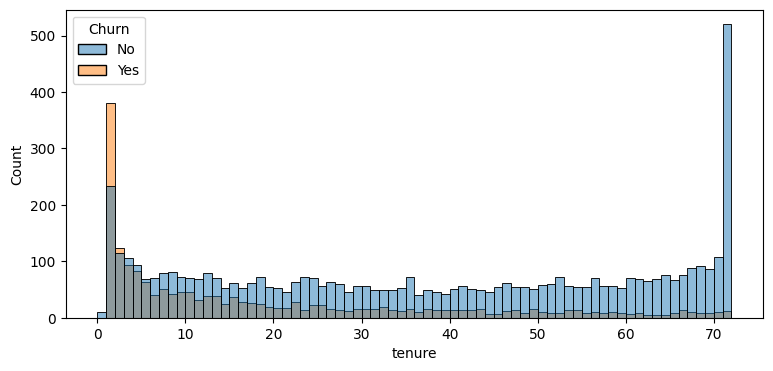

In [16]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure",data = df,bins = 72,hue = "Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our services #1 or 2 months have churned

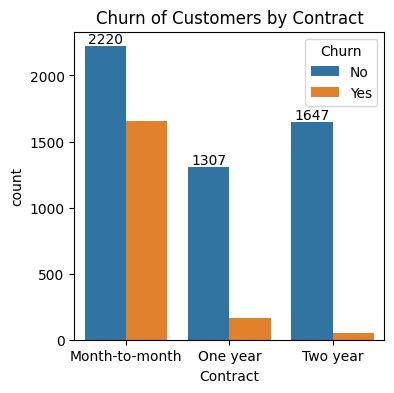

In [17]:
plt.figure (figsize= (4,4))
ax=sns.countplot(x= "Contract",data = df, hue ="Churn")
ax.bar_label(ax.containers[0])
plt.title("Churn of Customers by Contract")
plt.show()


#people who have month to month contract are likely to churn then from those who have 1 or 2 years of contracts

In [18]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

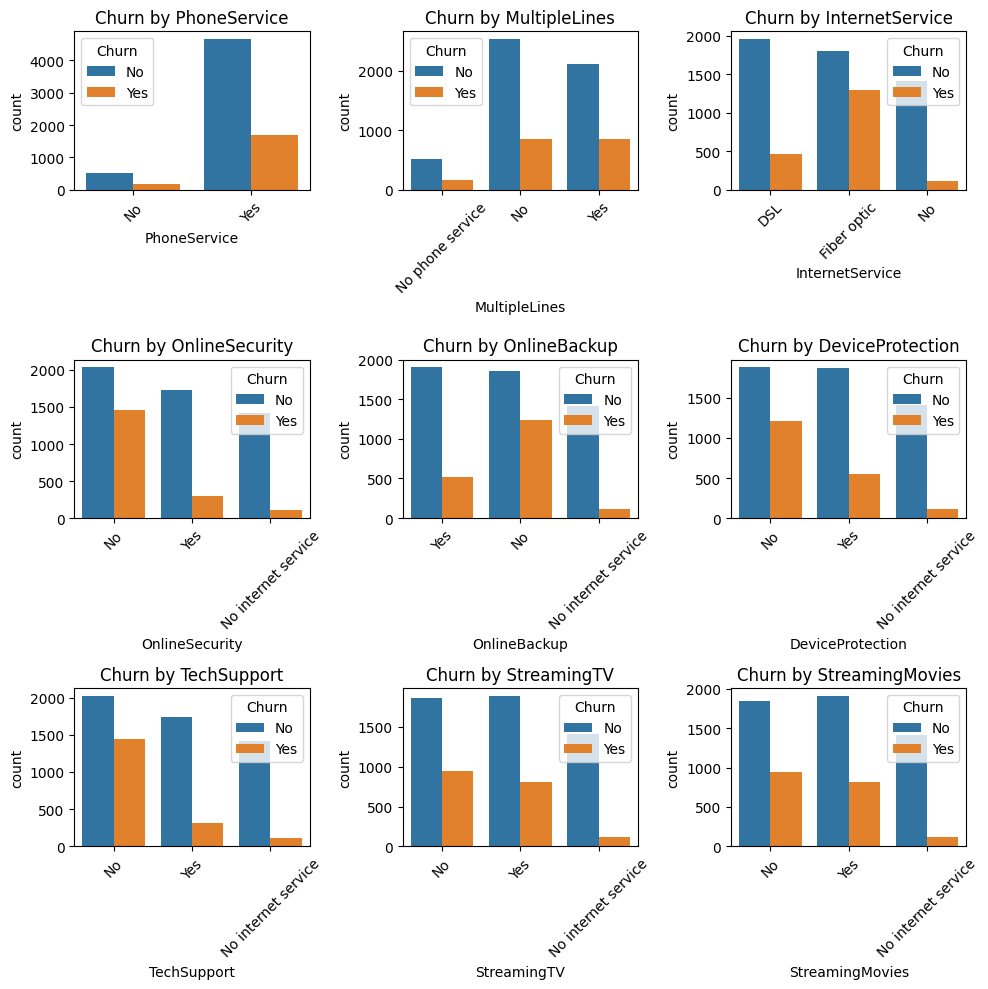

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to plot
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Set up the subplot grid (3 rows x 3 columns)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10,10))
axes = axes.flatten()  # Flatten so we can loop easily

# Create a countplot for each column
for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue='Churn', ax=axes[i])
    axes[i].set_title(f'Churn by {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x labels if needed

# Adjust layout
plt.tight_layout()
plt.show()


## The majority of customers who do not churn tend to have services like phoneservice ,internetservice (particularly DSL),and onlinesecurity enabled.for services like onlinebackup,techsupport, and streamingtv,churn rates are noticeably higher when these services are not  used or are unavailable.

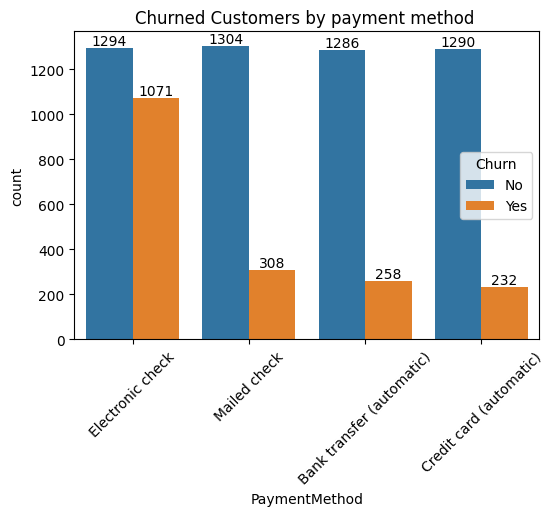

In [20]:
plt.figure (figsize= (6,4))
ax=sns.countplot(x= "PaymentMethod",data = df, hue ="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by payment method ")
plt.xticks(rotation = 45)
plt.show()


#customer is likely to churn when he is using electronic check as a pyament method

Customer Churn Analysis :
1. Overall Churn Rate
Total customers: 7,043

Customers who churned: 1,869 (26.54%)

Customers retained: 5,174 (73.46%)

Around 1 in 4 customers have left the company.

2. Churn by Gender
Churn rate is almost equal for males and females.

Gender is not a major factor in churn.

3. Churn by Senior Citizen Status
Senior citizens have significantly higher churn (47%) compared to non-senior citizens (23%).

Senior customers are more likely to leave.

4. Churn by Contract Type
Month-to-month contracts have the highest churn.

One-year and two-year contracts have much lower churn, indicating that long-term contracts help retain customers.

5. Churn by Services
Customers without Online Security, Tech Support, or Online Backup have higher churn.

Customers with fiber optic internet show higher churn than DSL users.

Lack of streaming services (TV or Movies) is also linked with higher churn.

No phone service is rare but not a major churn driver.

6. Churn by Payment Method
Electronic check users have the highest churn rate.

Customers paying by bank transfer or credit card have lower churn.

7. Key Insights
High-risk groups: Month-to-month customers, senior citizens, fiber optic internet users without security/backup services, and electronic check payers.

Retention strategies:

Encourage long-term contracts with discounts.

Offer bundled services like Online Security, Tech Support, and Backup.

Target senior citizens with tailored service plans.

Promote alternative payment methods over electronic checks.

If you want, I can also prepare a final conclusion and business recommendations section so you can directly paste it into your project report. This will make it look more professional.